In [1]:
import pandas as pd
import requests

# Descarga IPC mensual del INDEC
url = "https://apis.datos.gob.ar/series/api/series/?ids=148.3_INIVELNAL_DICI_M_26&limit=100&format=json"

response = requests.get(url)
data = response.json()

# Convertir a DataFrame
registros = data["data"]
df = pd.DataFrame(registros, columns=["fecha", "ipc"])
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

print(df.shape)
df.tail(10)

(100, 2)


,fecha,ipc
90,2024-06-01,6351.7145
91,2024-07-01,6607.7479
92,2024-08-01,6883.4412
93,2024-09-01,7122.2421
94,2024-10-01,7313.9542
95,2024-11-01,7491.4314
96,2024-12-01,7694.0075
97,2025-01-01,7864.1257
98,2025-02-01,8052.9927
99,2025-03-01,8353.3158


In [2]:
df["inflacion_mensual"] = df["ipc"].pct_change() * 100
df = df.dropna()

print(df.tail(10))

        fecha        ipc  inflacion_mensual
90 2024-06-01  6351.7145           4.577350
91 2024-07-01  6607.7479           4.030934
92 2024-08-01  6883.4412           4.172273
93 2024-09-01  7122.2421           3.469208
94 2024-10-01  7313.9542           2.691738
95 2024-11-01  7491.4314           2.426556
96 2024-12-01  7694.0075           2.704104
97 2025-01-01  7864.1257           2.211048
98 2025-02-01  8052.9927           2.401627
99 2025-03-01  8353.3158           3.729335


In [3]:
url_busqueda = "https://apis.datos.gob.ar/series/api/search/?q=tipo+de+cambio+oficial+BNA&limit=5&format=json"
response_busqueda = requests.get(url_busqueda)
print(response_busqueda.json())

{'data': [{'field': {'id': '175.1_DR_OFICNTA_0_0_19', 'description': 'Dólar Oficial. Venta', 'title': 'dolar_oficial_venta', 'frequency': 'R/P1D', 'time_index_start': '1976-03-08', 'time_index_end': '1989-12-19', 'units': 'Pesos', 'hits_90_days': '0'}, 'dataset': {'title': 'Tipos de Cambio Históricos', 'publisher': {'name': 'Subsecretaría de Programación Macroeconómica'}, 'source': 'Banco Central de la República Argentina (BCRA)', 'theme': 'Dinero y Bancos'}}, {'field': {'id': '175.1_DR_OFICPRA_0_0_20', 'description': 'Dólar Oficial. Compra', 'title': 'dolar_oficial_compra', 'frequency': 'R/P1D', 'time_index_start': '1976-03-08', 'time_index_end': '1989-12-19', 'units': 'Pesos', 'hits_90_days': '0'}, 'dataset': {'title': 'Tipos de Cambio Históricos', 'publisher': {'name': 'Subsecretaría de Programación Macroeconómica'}, 'source': 'Banco Central de la República Argentina (BCRA)', 'theme': 'Dinero y Bancos'}}, {'field': {'id': '168.1_T_CAMBIOR_D_0_0_26', 'description': 'Tipo de Cambio BN

In [4]:
url_tc = "https://apis.datos.gob.ar/series/api/series/?ids=168.1_T_CAMBIOR_D_0_0_26&limit=200&collapse=month&collapse_aggregation=end_of_period&format=json"

response_tc = requests.get(url_tc)
data_tc = response_tc.json()

df_tc = pd.DataFrame(data_tc["data"], columns=["fecha", "tipo_cambio"])
df_tc["fecha"] = pd.to_datetime(df_tc["fecha"])
df_tc = df_tc.sort_values("fecha").reset_index(drop=True)

# Filtramos solo datos reales (hasta donde tenemos IPC)
df_tc = df_tc[df_tc["fecha"] <= "2025-03-01"]

print(df_tc.tail(10))
print(df_tc.shape)

         fecha  tipo_cambio
114 2024-06-01       930.50
115 2024-07-01       951.50
116 2024-08-01       972.00
117 2024-09-01       990.00
118 2024-10-01      1011.50
119 2024-11-01      1031.00
120 2024-12-01      1052.50
121 2025-01-01      1073.50
122 2025-02-01      1084.25
123 2025-03-01      1093.50
(124, 2)


In [5]:
df_merge = pd.merge(df, df_tc, on="fecha", how="inner")

print(df_merge.shape)
print(df_merge.tail(10))

(99, 4)
        fecha        ipc  inflacion_mensual  tipo_cambio
89 2024-06-01  6351.7145           4.577350       930.50
90 2024-07-01  6607.7479           4.030934       951.50
91 2024-08-01  6883.4412           4.172273       972.00
92 2024-09-01  7122.2421           3.469208       990.00
93 2024-10-01  7313.9542           2.691738      1011.50
94 2024-11-01  7491.4314           2.426556      1031.00
95 2024-12-01  7694.0075           2.704104      1052.50
96 2025-01-01  7864.1257           2.211048      1073.50
97 2025-02-01  8052.9927           2.401627      1084.25
98 2025-03-01  8353.3158           3.729335      1093.50


In [6]:
df_merge.to_csv("../data/raw/datos_crudos.csv", index=False)
print("Guardado OK")

Guardado OK


In [7]:
url_busqueda = "https://apis.datos.gob.ar/series/api/search/?q=indice+salarios&limit=5&format=json"
response_busqueda = requests.get(url_busqueda)
data_busqueda = response_busqueda.json()

for item in data_busqueda["data"]:
    print(item["field"]["id"], "|", item["field"]["description"], "|", item["field"]["time_index_end"])

447.1_TOTALTAL_0_0_5_37 | Índice de salarios total | 2021-02-28
149.1_TL_INDIIOS_OCTU_0_21 | Índice de Salarios | 2026-01-01
149.1_TL_REGIADO_OCTU_0_16 | Índice de Salarios. Empleo registrado. | 2026-01-01
447.1_TOTAL_REGIADO_0_0_16_61 | Índice de salarios total registrado | 2021-02-28
18.1_NG_1997_A_13 | Índice de Salarios por Obrero (ISO). Índice General. Anuales | 2014-01-01


In [8]:
url_sal = "https://apis.datos.gob.ar/series/api/series/?ids=149.1_TL_INDIIOS_OCTU_0_21&limit=200&collapse=month&collapse_aggregation=end_of_period&format=json"

response_sal = requests.get(url_sal)
data_sal = response_sal.json()

df_sal = pd.DataFrame(data_sal["data"], columns=["fecha", "salarios"])
df_sal["fecha"] = pd.to_datetime(df_sal["fecha"])
df_sal = df_sal.sort_values("fecha").reset_index(drop=True)

print(df_sal.tail(10))
print(df_sal.shape)

         fecha  salarios
102 2025-04-01   6559.31
103 2025-05-01   6755.22
104 2025-06-01   6956.46
105 2025-07-01   7129.22
106 2025-08-01   7354.44
107 2025-09-01   7518.03
108 2025-10-01   7705.88
109 2025-11-01   7843.14
110 2025-12-01   7969.60
111 2026-01-01   8171.66
(112, 2)


In [9]:
df_final = pd.merge(df_merge, df_sal, on="fecha", how="inner")

print(df_final.shape)
print(df_final.tail(10))

(99, 5)
        fecha        ipc  inflacion_mensual  tipo_cambio  salarios
89 2024-06-01  6351.7145           4.577350       930.50   4329.80
90 2024-07-01  6607.7479           4.030934       951.50   4653.26
91 2024-08-01  6883.4412           4.172273       972.00   4916.19
92 2024-09-01  7122.2421           3.469208       990.00   5147.61
93 2024-10-01  7313.9542           2.691738      1011.50   5383.96
94 2024-11-01  7491.4314           2.426556      1031.00   5591.00
95 2024-12-01  7694.0075           2.704104      1052.50   5765.54
96 2025-01-01  7864.1257           2.211048      1073.50   5934.47
97 2025-02-01  8052.9927           2.401627      1084.25   6161.52
98 2025-03-01  8353.3158           3.729335      1093.50   6344.81


In [10]:
df_final.to_csv("../data/raw/datos_finales.csv", index=False)
print("Guardado OK")

Guardado OK


In [11]:
df_features = df_final.copy()

# Lags de inflacion
df_features["inflacion_lag1"] = df_features["inflacion_mensual"].shift(1)
df_features["inflacion_lag2"] = df_features["inflacion_mensual"].shift(2)
df_features["inflacion_lag3"] = df_features["inflacion_mensual"].shift(3)

# Variacion mensual del tipo de cambio
df_features["var_tc"] = df_features["tipo_cambio"].pct_change() * 100
df_features["var_tc_lag1"] = df_features["var_tc"].shift(1)
df_features["var_tc_lag2"] = df_features["var_tc"].shift(2)

# Variacion mensual de salarios
df_features["var_sal"] = df_features["salarios"].pct_change() * 100
df_features["var_sal_lag1"] = df_features["var_sal"].shift(1)

# Eliminamos filas con NaN que quedan por los lags
df_features = df_features.dropna().reset_index(drop=True)

print(df_features.shape)
print(df_features.tail(5))

(96, 13)
        fecha        ipc  inflacion_mensual  tipo_cambio  salarios  \
91 2024-11-01  7491.4314           2.426556      1031.00   5591.00   
92 2024-12-01  7694.0075           2.704104      1052.50   5765.54   
93 2025-01-01  7864.1257           2.211048      1073.50   5934.47   
94 2025-02-01  8052.9927           2.401627      1084.25   6161.52   
95 2025-03-01  8353.3158           3.729335      1093.50   6344.81   

    inflacion_lag1  inflacion_lag2  inflacion_lag3    var_tc  var_tc_lag1  \
91        2.691738        3.469208        4.172273  1.927830     2.171717   
92        2.426556        2.691738        3.469208  2.085354     1.927830   
93        2.704104        2.426556        2.691738  1.995249     2.085354   
94        2.211048        2.704104        2.426556  1.001397     1.995249   
95        2.401627        2.211048        2.704104  0.853124     1.001397   

    var_tc_lag2   var_sal  var_sal_lag1  
91     1.851852  3.845497      4.591451  
92     2.171717  3.1218

In [12]:
# Variable objetivo: inflacion del mes actual
# Features: todo lo demas excepto fecha, ipc e inflacion_mensual
X = df_features.drop(columns=["fecha", "ipc", "inflacion_mensual", "tipo_cambio", "salarios"])
y = df_features["inflacion_mensual"]

# Walk-forward: 80% train, 20% test respetando el orden temporal
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Train: {len(X_train)} meses")
print(f"Test: {len(X_test)} meses")
print(f"\nFeatures: {list(X.columns)}")

Train: 76 meses
Test: 20 meses

Features: ['inflacion_lag1', 'inflacion_lag2', 'inflacion_lag3', 'var_tc', 'var_tc_lag1', 'var_tc_lag2', 'var_sal', 'var_sal_lag1']


In [13]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

modelo = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE:  4.184
RMSE: 6.405


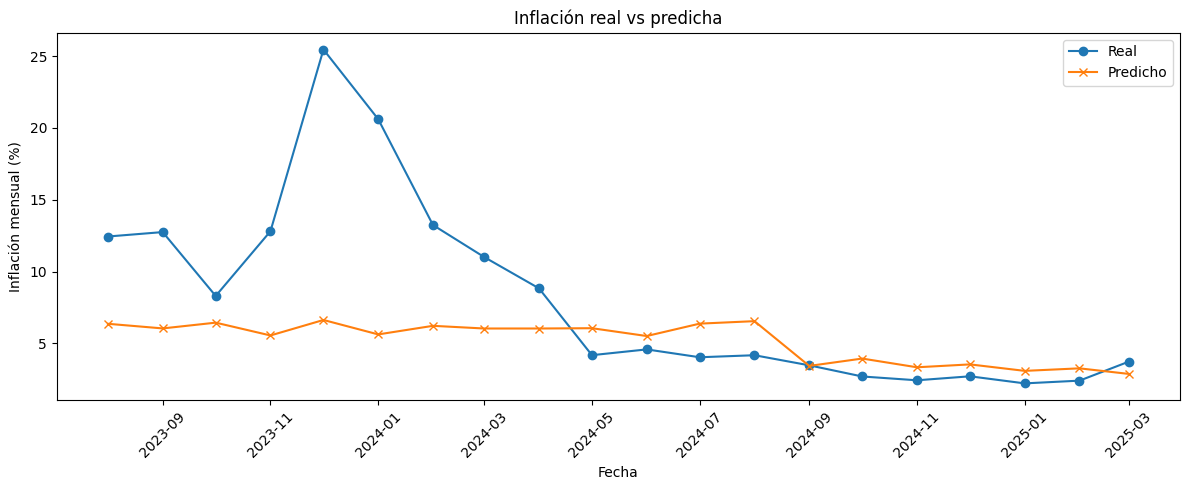

        fecha       real  predicho
0  2023-08-01  12.441638  6.361589
1  2023-09-01  12.749750  6.039644
2  2023-10-01   8.301739  6.440930
3  2023-11-01  12.810690  5.549521
4  2023-12-01  25.465675  6.627522
5  2024-01-01  20.614225  5.622205
6  2024-02-01  13.240676  6.220087
7  2024-03-01  11.009700  6.033703
8  2024-04-01   8.831921  6.033703
9  2024-05-01   4.176045  6.054580
10 2024-06-01   4.577350  5.509353
11 2024-07-01   4.030934  6.372936
12 2024-08-01   4.172273  6.545681
13 2024-09-01   3.469208  3.427897
14 2024-10-01   2.691738  3.939991
15 2024-11-01   2.426556  3.332479
16 2024-12-01   2.704104  3.533639
17 2025-01-01   2.211048  3.082544
18 2025-02-01   2.401627  3.258355
19 2025-03-01   3.729335  2.869794


In [14]:
import matplotlib.pyplot as plt

resultados = pd.DataFrame({
    "fecha": df_features["fecha"].iloc[split:].values,
    "real": y_test.values,
    "predicho": y_pred
})

plt.figure(figsize=(12, 5))
plt.plot(resultados["fecha"], resultados["real"], label="Real", marker="o")
plt.plot(resultados["fecha"], resultados["predicho"], label="Predicho", marker="x")
plt.title("Inflación real vs predicha")
plt.xlabel("Fecha")
plt.ylabel("Inflación mensual (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(resultados)

In [15]:
df_features["var_tc_3m"] = df_features["tipo_cambio"].pct_change(3) * 100
df_features["inflacion_3m"] = df_features["inflacion_mensual"].rolling(3).mean().shift(1)

df_features = df_features.dropna().reset_index(drop=True)

X = df_features.drop(columns=["fecha", "ipc", "inflacion_mensual", "tipo_cambio", "salarios"])
y = df_features["inflacion_mensual"]

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

modelo2 = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
modelo2.fit(X_train, y_train)

y_pred2 = modelo2.predict(X_test)

mae2 = mean_absolute_error(y_test, y_pred2)
rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))

print(f"MAE:  {mae2:.3f}")
print(f"RMSE: {rmse2:.3f}")

MAE:  3.455
RMSE: 5.633


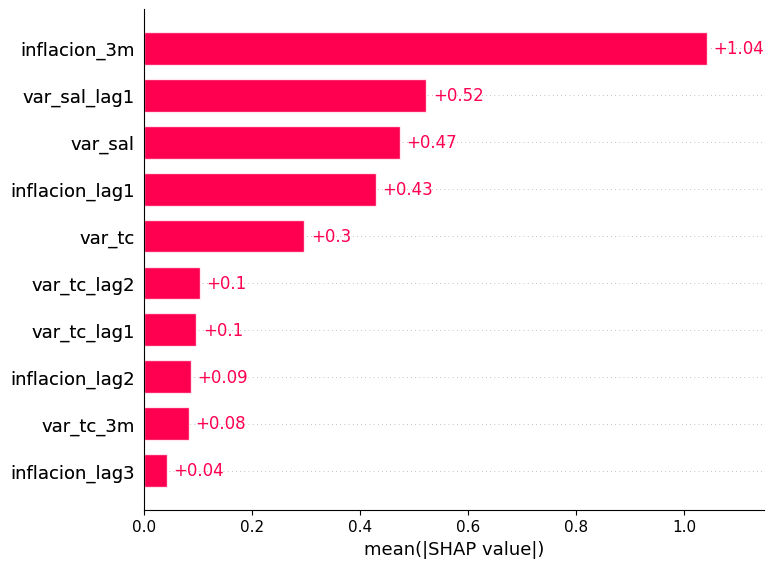

In [16]:
import shap

explainer = shap.Explainer(modelo2)
shap_values = explainer(X_test)

shap.plots.bar(shap_values)

In [17]:
import pickle

with open("../data/modelo.pkl", "wb") as f:
    pickle.dump(modelo2, f)

print("Modelo guardado OK")

Modelo guardado OK
